# Set-up

In [1]:
import os
from google.colab import userdata

# Get the token from the Secrets pane
github_token = userdata.get('Crecerelle-GitHub-Access')

# Set it as an environment variable for pip
os.environ['Crecerelle-GitHub-Access'] = github_token

# @markdown **Crecerelle:** Install the library from GitHub
#!pip install git+https://{os.environ['Crecerelle-GitHub-Access']}@github.com/fweberling/crecerelle.git
!pip install git+https://{os.environ['Crecerelle-GitHub-Access']}@github.com/fweberling/crecerelle.git "pandas==2.2.2"

  Cloning https://****@github.com/fweberling/crecerelle.git to /tmp/pip-req-build-jy6ilic9
  Running command git clone --filter=blob:none --quiet 'https://****@github.com/fweberling/crecerelle.git' /tmp/pip-req-build-jy6ilic9
  Resolved https://****@github.com/fweberling/crecerelle.git to commit b59a63796106852935249cb01ccc28183ce33b43
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of scanpy to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 115.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 120.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.8/394.8 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# @markdown **Directory structure:** Set-up the directory structure to store the results of Crecerelle. We recommend connecting to your Google Drive. Otherwise, the directories will be created only temporarily in Colab. If you have already set-up the directory structure from a previous analysis, the existing directories will not be overwritten but only the new ones added.

connect_google_drive = True # @param {type:"boolean"}

if connect_google_drive:
    from google.colab import drive
    drive.mount('/content/drive')

    root_directory = "/content/drive/My Drive"
else:
    root_directory = "/content"

Mounted at /content/drive


The following directory structure is then created:
```text
root_directory/
└── crecerelle_results/
    ├── data/
    │   └── <dataset_name>/  *(optional)*
    ├── figures/
    │   └── <dataset_name>/  *(optional)*
    └── models/
        ├── scGETUVI/
        ├── scTUVI/
        └── scVI/

In [3]:
from crecerelle.utils import setup_crecerelle

# @markdown **Dataset name:** Define the dataset name
dataset_name = "tabulaMuris" # @param

# Set-up the directory structure
setup_crecerelle(root_directory, dataset_name=dataset_name)

# @markdown The working directory is then set to "./crecerelle_results"
if os.path.basename(os.path.normpath(os.getcwd())) != "crecerelle_results":
    os.chdir("drive/My Drive/crecerelle_results")

# Print the working directory
print(f"The working directory is set to: {os.getcwd()}")

Skipped (already exists): /content/drive/My Drive/crecerelle_results
Skipped (already exists): /content/drive/My Drive/crecerelle_results/models
Skipped (already exists): /content/drive/My Drive/crecerelle_results/data
Skipped (already exists): /content/drive/My Drive/crecerelle_results/figures
Skipped (already exists): /content/drive/My Drive/crecerelle_results/models/scVI
Skipped (already exists): /content/drive/My Drive/crecerelle_results/models/scTUVI
Skipped (already exists): /content/drive/My Drive/crecerelle_results/models/scGETUVI
Skipped (already exists): /content/drive/My Drive/crecerelle_results/data/tabulaMuris
Skipped (already exists): /content/drive/My Drive/crecerelle_results/figures/tabulaMuris
The working directory is set to: /content/drive/My Drive/crecerelle_results


In [4]:
# @markdown **Imports:** modules from PyTorch, Numpy, Scanpy amongst others are imported together with the crecerelle modules necessary for scGETUVI
# General import
import numpy as np
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
from umap import UMAP
import scib
import pdb
import pandas as pd

# Imports from crecerelle
from crecerelle.models import SCGETUVI
from crecerelle.cell import TABULA_MURIS_CELL_TYPES, MOUSE_CORTEX_BICCN_CELL_TYPES, TABULA_MURIS_TISSUE_ORGAN_SYSTEM_DICT, TABULA_MURIS_CELL_TYPE_ABBREVIATION_DICT
from crecerelle.utils import GeneExpressionTranscriptUsageDataset, intron_names_2_integers

# Settings for plotting
plt.rcParams.update({
    'font.size': 16,              # General font size
    'axes.labelsize': 16,         # Font size for x and y labels
    'axes.titlesize': 16,         # Font size for subplot titles
    'xtick.labelsize': 16,        # Font size for x-axis tick labels
    'ytick.labelsize': 16,        # Font size for y-axis tick labels
    'legend.fontsize': 16,        # Font size for legend labels
    #'font.family': 'sans-serif',
    #'font.sans-serif': 'Roboto',
    # 'figure.titlesize': 10,    # Font size for the overall figure title (if you use it)
})

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
# @markdown **Specify settings:** These are the general settings for keys to be defined. They are stored in a dictionary called settings. The dataset_name key is already saved in it. The current settings contain the default version for the Tabula Muris dataset.

# @markdown Key of Anndata object specifiying the cell type
settings_cell_type_key = "cell_ontology_class" # @param

# @markdown  Cell types of dataset given
settings_cell_types = TABULA_MURIS_CELL_TYPES # @param

# @markdown Abbreviations of cell types
settings_cell_type_abbreviations = TABULA_MURIS_CELL_TYPE_ABBREVIATION_DICT # @param

# @markdown Organisational entity of cell groups (e.g. tissue)
settings_cell_type_groups_key = "tissue" # @param

# @markdown Name of gene annotation file
settings_gene_annotation = "Mus_musculus.GRCm38.102.chr.gtf.gz" # @param

# @markdown Number of highly variable genes selected (HVGs)
settings_num_hvg = 3000 # @param

# @markdown Data partition used (recommended: "full") for tasks
settings_data_type = "full" # @param

# @markdown Key of Anndata object specifying the data partition (e.g. "train", "val", "test)
settings_data_partition_key = "data_partition" # @param

# @markdown Filter data to cell types with a minimum count
settings_filter_cell_types = True # @param {type:"boolean"}

# @markdown Minimum count threshold for filtering if filter_cell_types is True
settings_min_count_threshold = 100 # @param {type:"integer"}

settings = {
    "dataset_name": dataset_name, # Name of dataset
    "cell_type_key": settings_cell_type_key, # Key of Anndata object specifiying the cell type
    "cell_types": settings_cell_types, # Cell types of dataset given
    "cell_type_abbreviations": settings_cell_type_abbreviations, # Abbreviations of cell types
    "cell_type_groups_key": settings_cell_type_groups_key, # Organisational entity of cell groups (e.g. tissue)
    "gene_annotation": settings_gene_annotation,
    "num_hvg": settings_num_hvg, # Number of highly variable genes selected (HVGs)
    "data_type": settings_data_type, # Data partition used (recommended: "full") for tasks
    "data_partition_key": settings_data_partition_key,
    "filter_cell_types": settings_filter_cell_types, # Filter data to cell types with a minimum count
    "min_count_threshold": settings_min_count_threshold, # Minimum count threshold for filtering if filter_cell_types is True
}

In [6]:
# @markdown All data files must be stored here and the resulting new data will also be stored here.
path2data = "./data/" + settings["dataset_name"] + "/"

print(f"The data files will be stored in: {path2data}")

The data files will be stored in: ./data/tabulaMuris/


# Loading data

Ensure the Anndata objects of the gene expression and transcript usage data are uploaded in "./crecerelle_results/data/dataset_name" *(optional)*. The object containing the gene expression matrix should have the prefix "adata_GE" whereas the one containing the transcript usage matrix should start with "adata_TU". Examples are:




*   adata_GE_{data_type}_preprocessed.h5ad
    *   e.g. adata_GE_full_preprocessed.h5ad
*   adata_TU_{data_type}_preprocessed.h5ad
    *   e.g. adata_TU_full_preprocessed.h5ad
*   adata_GE_{num_hvg}_{data_partition}.h5ad
    *   adata_GE_3000_train.h5ad
    *   adata_GE_3000_val.h5ad
    *   adata_GE_3000_test.h5ad

In [7]:
# @markdown **Dataset:** Create the combined dataset of gene expression and transcript usage for inference with scGETUVI

hvg_annotation = np.load(path2data + "full_" + str(settings["num_hvg"]) + "_hvg_annotation.npy")

if settings["data_type"]  != "full":
    # Load gene expression data of specified data partition
    adata_GE = ad.read_h5ad(path2data + "adata_GE_" + settings["data_type"]  + "_preprocessed.h5ad")
    adata_GE = adata_GE[:, hvg_annotation].copy()
    adata_GE.obs[settings["data_partition_key"]] = settings["data_type"]

    print(f"Following Anndata object contains the gene expression data of the data partition {settings["data_type"]}: \n {adata_GE}")

    # Load transcript usage data of specified data partition
    adata_TU = ad.read_h5ad(path2data + "adata_TU_" + settings["data_type"]  + "_preprocessed.h5ad")
    intron_groups_by_name = adata_TU.var["intron_group"].values
    intron_groups = intron_names_2_integers(intron_groups_by_name)
    unique_intron_groups, _ = np.unique(intron_groups, return_index=True)
    num_intron_groups = len(unique_intron_groups)
    adata_TU.obs[settings["data_partition_key"]] = settings["data_type"]

    print(f"Following Anndata object contains the transcript usage data of the data partition {settings["data_type"]}: \n {adata_TU}")
else:
    # Load gene expression training data
    adata_GE_train = ad.read_h5ad(path2data + "adata_GE_" + str(settings["num_hvg"]) + "_train.h5ad")
    adata_GE_train = adata_GE_train[:, hvg_annotation].copy()
    adata_GE_train.obs[settings["data_partition_key"]] = "train"

    # Load transcript usage training data
    adata_TU_train = ad.read_h5ad(path2data + "adata_TU_" + str(settings["num_hvg"]) + "_train.h5ad")
    intron_groups_by_name = adata_TU_train.var["intron_group"].values
    intron_groups = intron_names_2_integers(intron_groups_by_name)
    unique_intron_groups, _ = np.unique(intron_groups, return_index=True)
    num_intron_groups = len(unique_intron_groups)
    adata_TU_train.obs[settings["data_partition_key"]] = "train"

    # Load gene expression validation data
    adata_GE_val = ad.read_h5ad(path2data + "adata_GE_" + str(settings["num_hvg"]) + "_val.h5ad")
    adata_GE_val = adata_GE_val[:, hvg_annotation].copy()
    adata_GE_val.obs[settings["data_partition_key"]] = "val"

    # Load transcript usage validation data
    adata_TU_val = ad.read_h5ad(path2data + "adata_TU_" + str(settings["num_hvg"]) + "_val.h5ad")
    adata_TU_val.obs[settings["data_partition_key"]] = "val"

    # Load gene expression test data
    adata_GE_test = ad.read_h5ad(path2data + "adata_GE_" + str(settings["num_hvg"]) + "_test.h5ad")
    adata_GE_test = adata_GE_test[:, hvg_annotation].copy()
    adata_GE_test.obs[settings["data_partition_key"]] = "test"

    # Load transcript usage test data
    adata_TU_test = ad.read_h5ad(path2data + "adata_TU_" + str(settings["num_hvg"]) + "_test.h5ad")
    adata_TU_test.obs[settings["data_partition_key"]] = "test"

    if settings["filter_cell_types"]:
        cell_types, cell_counts = np.unique(adata_GE_train.obs[settings["cell_type_key"]].to_numpy(), return_counts=True)
        filtered_cell_types = cell_types[np.argwhere(cell_counts >= settings["min_count_threshold"])].squeeze()

        # Filter adata_GE_train, adata_GE_val, adata_GE_test to filtered_cell_types
        adata_GE_train_filtered = adata_GE_train[adata_GE_train.obs[settings["cell_type_key"]].isin(filtered_cell_types)].copy()
        adata_GE_val_filtered = adata_GE_val[adata_GE_val.obs[settings["cell_type_key"]].isin(filtered_cell_types)].copy()
        adata_GE_test_filtered = adata_GE_test[adata_GE_test.obs[settings["cell_type_key"]].isin(filtered_cell_types)].copy()

        adata_GE_train = adata_GE_train_filtered
        adata_GE_val = adata_GE_val_filtered
        adata_GE_test = adata_GE_test_filtered

        # Filter adata_TU_train, adata_TU_val, adata_TU_test accordingly
        adata_TU_train_filtered = adata_TU_train[adata_TU_train.obs[settings["cell_type_key"]].isin(filtered_cell_types)].copy()
        adata_TU_val_filtered = adata_TU_val[adata_TU_val.obs[settings["cell_type_key"]].isin(filtered_cell_types)].copy()
        adata_TU_test_filtered = adata_TU_test[adata_TU_test.obs[settings["cell_type_key"]].isin(filtered_cell_types)].copy()

        adata_TU_train = adata_TU_train_filtered
        adata_TU_val = adata_TU_val_filtered
        adata_TU_test = adata_TU_test_filtered

        print(f"Cell types with less than {settings["min_count_threshold"]} have been filtered out. \n")

    adata_GE = ad.concat([adata_GE_train, adata_GE_val, adata_GE_test], axis=0, join="outer", merge="same")
    adata_TU = ad.concat([adata_TU_train, adata_TU_val, adata_TU_test], axis=0, join="outer", merge="same")

# @markdown **Optional: Filter cells in taxonomy level:** Per taxonomy level, filter out all cell types with less than min_cells (if not set to 0)
min_cells_per_tax_level = 50 # @param {type:"integer"}

if min_cells_per_tax_level > 0:
    # 1. Calculate the size of each cell type group within each tissue
    # transform('size') returns a Series with the same index as the original dataframe
    counts = adata_TU.obs.groupby([settings["cell_type_groups_key"], settings["cell_type_key"]])[settings["cell_type_key"]].transform('size')

    # 2. Create a boolean mask for cells to keep
    keep_mask = counts >= min_cells_per_tax_level

    # 3. Slice both AnnData objects in the tuple
    adata_TU_filtered = adata_TU[keep_mask, :].copy()
    adata_GE_filtered = adata_GE[keep_mask, :].copy()

    adata_TU_filtered.obs[settings["cell_type_key"]] = adata_TU_filtered.obs[settings["cell_type_key"]].cat.remove_unused_categories()
    adata_GE_filtered.obs[settings["cell_type_key"]] = adata_GE_filtered.obs[settings["cell_type_key"]].cat.remove_unused_categories()

    adata_TU = adata_TU_filtered.copy()
    adata_TU_train = adata_TU[adata_TU.obs[settings["data_partition_key"]] == "train", :].copy()
    adata_TU_val = adata_TU[adata_TU.obs[settings["data_partition_key"]] == "val", :].copy()
    adata_TU_test = adata_TU[adata_TU.obs[settings["data_partition_key"]] == "test", :].copy()

    adata_GE = adata_GE_filtered.copy()
    adata_GE_train = adata_GE[adata_GE.obs[settings["data_partition_key"]] == "train", :].copy()
    adata_GE_val = adata_GE[adata_GE.obs[settings["data_partition_key"]] == "val", :].copy()
    adata_GE_test = adata_GE[adata_GE.obs[settings["data_partition_key"]] == "test", :].copy()

    print(f"Cell types with less than {min_cells_per_tax_level} cells per taxonomy level have been filtered out. \n")

print(f"Following Anndata object contains the gene expression data of the data partition {settings["data_type"]}: \n {adata_GE}")

print(f"Following Anndata object contains the transcript usage data of the data partition {settings["data_type"]}: \n {adata_TU} \n")

# Extract gene expression training data from AnnData object
cell_gene_counts = torch.from_numpy(adata_GE.layers["counts"].toarray())
cell_gene_levels = torch.from_numpy(adata_GE.X.toarray())

# Extract transript usage training data from AnnData object
cell_intron_counts = torch.from_numpy(adata_TU.layers["counts"].toarray())
cell_intron_levels = torch.from_numpy(adata_TU.X.toarray())

transform_gene_counts = None
transform_ontology = "one-hot"
transform_intron_counts = None # Previously "log" but incorrect
transform_intron_levels = None

gene_transcript_dataset = GeneExpressionTranscriptUsageDataset(
    cell_gene_counts=cell_gene_counts,
    cell_gene_levels=cell_gene_levels,
    cell_intron_counts=cell_intron_counts,
    cell_intron_levels=cell_intron_levels,
    ontology=adata_GE.obs[settings["cell_type_key"]].to_numpy(),
    tissue=adata_GE.obs[settings["cell_type_groups_key"]].to_numpy(),
    cell_types=cell_types,
    transform_gene_counts=transform_gene_counts,
    transform_intron_counts=transform_intron_counts,
    transform_intron_levels=transform_intron_levels,
    transform_ontology=transform_ontology
)

print(f"The dataset is set up for inference.")

Cell types with less than 100 have been filtered out. 



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_1217/197147561.py:87: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = adata_TU.obs.groupby([settings["cell_type_groups_key"], settings["cell_type_key"]])[settings["cell_type_key"]].transform('size')
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetim

Cell types with less than 50 cells per taxonomy level have been filtered out. 

Following Anndata object contains the gene expression data of the data partition full: 
 AnnData object with n_obs × n_vars = 36256 × 3000
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'cell_type', 'plate_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'data_partition'
    var: 'gene_id', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'lo

# Model settings for scGETUVI

In [8]:
# @markdown **Path to models:** Ensure all scTUVI models trained have been saved in this path
settings_path2models = "./models/scGETUVI/" # @param
settings["path2models"] = settings_path2models

print(f"The scGETUVI models trained are chosen from the path {settings["path2models"]}")
print(f"Currently, follwing models are present in {settings["path2models"]}: ")

from pathlib import Path
for model_file in Path(settings["path2models"]).iterdir():
    print(model_file.name)

The scGETUVI models trained are chosen from the path ./models/scGETUVI/
Currently, follwing models are present in ./models/scGETUVI/: 
Archive
tabulaMuris_3000_scGETUVI_1_ZINB_ZIDM_010_epochs_465_checkpoint.pth
tabulaMuris_3000_scGETUVI_2_ZINB_ZIDM_010_epochs_550_checkpoint.pth
tabulaMuris_3000_scGETUVI_0_ZINB_ZIDM_010_epochs_603_checkpoint.pth
tabulaMuris_3000_scGETUVI_4_ZINB_ZIDM_010_epochs_413_checkpoint.pth
tabulaMuris_3000_scGETUVI_5_ZINB_ZIDM_010_epochs_575_checkpoint.pth
tabulaMuris_3000_scGETUVI_3_ZINB_ZIDM_010_epochs_577_checkpoint.pth
tabulaMuris_3000_scGETUVI_6_ZINB_ZIDM_010_epochs_310_checkpoint.pth
tabulaMuris_3000_scGETUVI_8_ZINB_ZIDM_010_epochs_324_checkpoint.pth
tabulaMuris_3000_scGETUVI_7_ZINB_ZIDM_010_epochs_361_checkpoint.pth
tabulaMuris_3000_scGETUVI_9_ZINB_ZIDM_010_epochs_542_checkpoint.pth


In [9]:
# @markdown **Model specification of scGETUVI**

# @markdown **Dimension of latent spaces:** Define the dimensionality of the private gene expression embeddings (latent_dim_1), of the private transcript usage embeddings (latent_dim_2), and the shared embeddings (latent_dim_shared)

# input_dim[0] for gene expression, input_dim[1] for transcript usage
input_dim = [gene_transcript_dataset.num_genes, gene_transcript_dataset.num_introns]

# number of intron groups for transcript usage # TO DO ELIMINATE THIS PARAMETER LATER
num_intron_groups = num_intron_groups

# intron groups for transcript usage # TO DO ELIMINATE THIS PARAMETER LATER
intron_groups = intron_groups

# latent_dim[0] for gene expression, latent_dim[1] for transcript usage, latent_dim[2] for shared latent
latent_dim_1 = 10 # @param {type:"integer"}
latent_dim_2 = 10 # @param {type:"integer"}
latent_dim_shared = 10 # @param {type:"integer"}
latent_dim = [latent_dim_1, latent_dim_2, latent_dim_shared]

# @markdown **Beta parameter:** Choose the value for the beta parameter for gene expression and transcript usage
# beta[0] for gene expression, beta[1] for transcript usage
beta_1 = 1.0 # @param {type:"number"}
beta_2 = 1.0 # @param {type:"number"}
beta = [beta_1, beta_2]

# @markdown **Architecture of neural networks:** choose the number of hidden layers as well as the number of hidden units per layer for the encoding and decoding neural networks of gene expression (num_hidden_layers_1, num_hidden_units_1) and transcript usage (num_hidden_layers_2, num_hidden_units_2)
# num_hidden_layers[0] for gene expression, num_hidden_layers[1] for transcript usage
num_hidden_layers_1 = 2 # @param {type:"integer"}
num_hidden_layers_2 = 2 # @param {type:"integer"}
num_hidden_layers = [num_hidden_layers_1, num_hidden_layers_2]

# num_hidden_units[0] for gene expression, num_hidden_units[1] for transcript usage
num_hidden_units_1 = 256 # @param {type:"integer"}
num_hidden_units_2 = 256 # @param {type:"integer"}
num_hidden_units = [num_hidden_units_1, num_hidden_units_2]

# @markdown **Observation model:** Choose the data likelihood of the gene expression data (likelihood_1) and of the transcript usage data (likelihood_2).
# likelihoods[0] for gene expression, likelihoods[1] for transcript usage
likelihood_1 = "ZINB" # @param ["ZINB", "NB","Gaussian"]
likelihood_2 = "ZIDM" # @param ["ZANIDM", "ZIDM", "DM"]
likelihoods = [likelihood_1, likelihood_2]

# @markdown **Data modality weighting:** Tick the box, if the importance of each modality for each data point shall be learnt
# Learn weighting of modalities
learn_modality_weighting = True # @param {type:"boolean"}

# @markdown **Dropout rate:** If dropout shall be applied, set the dropout rate to 0.0 > p > 1.0. Otherwise, choose 0.0.
dropout_rate = 0.1 # @param {type:"number"}
device = "cuda" # @param ["cuda", "cpu"]

scaling_factor_1 = False # @param {type:"boolean"}
scaling_factor_2 = False # @param {type:"boolean"}
scaling_factor = [scaling_factor_1, scaling_factor_2]

# Convert beta to string
for beta_i in beta:
    beta_str = f"{beta_i:.1f}"
    beta_str = beta_str.replace(".", "")
    while len(beta_str) < 3:
        beta_str = "0" + beta_str
    beta_str = beta_str

from crecerelle.models import SCGETUVI

model = SCGETUVI(
    input_dim=input_dim,
    num_intron_groups=num_intron_groups,
    intron_groups=intron_groups,
    latent_dim=latent_dim,
    beta=beta,
    num_hidden_layers=num_hidden_layers,
    num_hidden_units=num_hidden_units,
    likelihoods=likelihoods,
    scaling_factor=scaling_factor,
    temp=500, # Parameter is now used as final value for modality regularisation
    learn_modality_weighting=learn_modality_weighting,
    dropout_rate=dropout_rate,
    device=device,
)

print(f"The given model specification for scGETUVI yields: \n {model}")



The given model specification for scGETUVI yields: 
 SCGETUVI(
  (vae_1): ZINBGeneExpressionVAE(
    (encoder): Encoder(
      (encoder): FCLayers(
        (fc_layers): ModuleList(
          (0): Sequential(
            (linear): Linear(in_features=3000, out_features=256, bias=True)
            (batchnorm): BatchNorm1d(256, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (activation): ReLU()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): Sequential(
            (linear): Linear(in_features=256, out_features=256, bias=True)
            (batchnorm): BatchNorm1d(256, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (activation): ReLU()
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
      )
      (mean_encoder): Linear(in_features=256, out_features=20, bias=True)
      (var_encoder): Linear(in_features=256, out_features=20, bias=True)
    )
    (decoder): ZINBGeneExpression

/usr/local/lib/python3.12/dist-packages/crecerelle/models.py:1560: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  torch.sparse_coo_tensor(


# Comparisaon of different random seeds for scGETUVI

To select the model, define the seeds and the corresponding epoch checkpoints of the scGETUVI models you want to evaluate. Then, choose an evaluation metric to asses the fidelity of the learnt generative model (e.g. negative log-likelihood (nll), root mean squared error (rmse)). We recommend the negative log-likelihood (nll). For the Tabula Muris we had following seeds and epoch checkpoints:

*   scGETUVI-ZINB-ZIDM:
    *   seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
    *   epoch checkpoints: [603, 465, 550, 577, 413, 575, 310, 361, 324, 542]

In [10]:
# @markdown **List of random seeds:** Define the random seeds to be evaluated
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] # @param

# @markdown **Epoch checkpoints:** Choose per seed selected the according epoch checkpoint
epoch_checkpoints = [603, 465, 550, 577, 413, 575, 310, 361, 324, 542] # @param

# @markdown **Evaluation metric:** Choose the evaluation metric
eval_metric = "nll" # @param ["nll", "rmse"]

Across the models and their seeds chosen, the robustness is evaluated by calculating the overall average of the evaluation metric and the overall standard deviation for both gene expression and transcript usage. We recommend to use models beneath both thresholds for both gene expression and transcript usage. The chosen model can then be used for downstream tasks.

In [11]:
from crecerelle.utils import run_random_seed_evaluation_SCGETUVI

adata_GE_eval = adata_GE.copy()
adata_TU_eval = adata_TU.copy()
dataset = gene_transcript_dataset
model.eval()

batch_size = 256

# Run random seed evaluation
adata_GE_eval, adata_TU_eval = run_random_seed_evaluation_SCGETUVI(
        model,
        likelihoods=likelihoods,
        beta_str=beta_str,
        list_of_random_seeds=seeds,
        list_of_epoch_checkpoints=epoch_checkpoints,
        adata=(adata_GE_eval, adata_TU_eval),
        dataset=dataset,
        dataset_name=settings["dataset_name"],
        num_hvg=settings["num_hvg"],
        path2models=settings["path2models"],
        device=device,
        count_data_included=[True, True],
        batch_size=batch_size,
)

print(f"Random seeds have been evaluated for {seeds} and the results saved in the gene expression and transcript usage AnnData objects  \n {adata_GE_eval} \n {adata_TU_eval}")


Random seeds have been evaluated for [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] and the results saved in the gene expression and transcript usage AnnData objects  
 AnnData object with n_obs × n_vars = 36256 × 3000
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'cell_type', 'plate_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'data_partition', 'ZINB_0_weighting', 'ZINB_0_nll', 'ZINB_1_weighting', 'ZINB_1_nll', 'ZINB_2_weighting', 'ZINB_2_nll', 'ZINB_3_weighting', 'ZINB_3_nll', 'ZINB_4_weighting', 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


To assess the robustness the random seeds of scGETUVI, the performance of the generative model is assessed by the evaluation metric chosen.

In [12]:
# Evaluate reconstructions
from crecerelle.utils import evaluate_random_seeds_reconstructions

from crecerelle.utils import evaluate_random_seeds_reconstructions
eval_metric_df_GE = evaluate_random_seeds_reconstructions(
    seeds,
    adata_GE_eval,
    likelihoods[0],
    "test",
    eval_metric
)

eval_metric_df_TU = evaluate_random_seeds_reconstructions(
    seeds,
    adata_TU_eval,
    likelihoods[1],
    "test",
    eval_metric
)

# Calculate mean and std
eval_metric_df_GE_mean = eval_metric_df_GE.mean()
eval_metric_df_GE_std = eval_metric_df_GE.std()
eval_metric_df_TU_mean = eval_metric_df_TU.mean()
eval_metric_df_TU_std = eval_metric_df_TU.std()

# Rename the samples into "seed 1", "seed 2" etc
eval_metric_df_GE_mean.index = ["seed " + str(seed) for seed in seeds]
eval_metric_df_GE_std.index = ["seed " + str(seed) for seed in seeds]

eval_metric_df_TU_mean.index = ["seed " + str(seed) for seed in seeds]
eval_metric_df_TU_std.index = ["seed " + str(seed) for seed in seeds]

# Rename the series so they become the column names in the new DataFrame
eval_metric_df_GE_mean.name = "GE: Mean of " + eval_metric
eval_metric_df_GE_std.name = "GE: Std of " + eval_metric
eval_metric_df_TU_mean.name = "TU: Mean of " + eval_metric
eval_metric_df_TU_std.name = "TU: Std of " + eval_metric


# Concatenate them along columns (axis=1)
eval_metric_mean_std_df = pd.concat(
    [
        eval_metric_df_GE_mean,
        eval_metric_df_GE_std,
        eval_metric_df_TU_mean,
        eval_metric_df_TU_std
    ],
    axis=1
)

# @markdown **Save evaluation:**
save_eval_metric = True #@param {type:"boolean"}
if save_eval_metric:
    # Save the single merged DataFrame instead of two separate files
    eval_metric_mean_std_df.to_csv(path2data + "model_selection_scGETUVI_eval_metric_summary.csv")
    print(f"The evaluation metric summary is saved in {path2data}")

The evaluation metric summary is saved in ./data/tabulaMuris/


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [13]:
# Display the evaluation metric data frame
eval_metric_mean_std_df

,GE: Mean of nll,GE: Std of nll,TU: Mean of nll,TU: Std of nll
seed 0,1094.948975,533.816101,294.348999,177.340332
seed 1,1094.659180,518.792419,338.748077,210.181091
seed 2,1059.806641,485.853455,279.719940,172.274368
seed 3,1077.181763,460.031982,285.874847,205.507980
seed 4,1077.083252,461.200256,259.769440,142.033493
seed 5,1104.434692,506.280731,329.803955,268.040771
seed 6,1050.538818,443.834991,229.407883,102.987724
seed 7,1140.275879,1200.165894,258.110260,122.579674
seed 8,1044.347412,429.198486,229.593231,104.583687
seed 9,1070.998047,466.192505,287.122314,156.484726


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Display the evaluation metric data frame
eval_metric_mean_std_df

,GE: Mean of nll,GE: Std of nll,TU: Mean of nll,TU: Std of nll
seed 0,1094.948975,533.816101,294.348999,177.340332
seed 1,1094.659180,518.792419,338.748077,210.181091
seed 2,1059.806641,485.853455,279.719940,172.274368
seed 3,1077.181763,460.031982,285.874847,205.507980
seed 4,1077.083252,461.200256,259.769440,142.033493
seed 5,1104.434692,506.280731,329.803955,268.040771
seed 6,1050.538818,443.834991,229.407883,102.987724
seed 7,1140.275879,1200.165894,258.110260,122.579674
seed 8,1044.347412,429.198486,229.593231,104.583687


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
adata_GE_eval

AnnData object with n_obs × n_vars = 36256 × 3000
    obs: 'FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'cell_type', 'plate_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'data_partition', 'ZINB_0_weighting', 'ZINB_0_nll', 'ZINB_1_weighting', 'ZINB_1_nll', 'ZINB_2_weighting', 'ZINB_2_nll', 'ZINB_3_weighting', 'ZINB_3_nll', 'ZINB_4_weighting', 'ZINB_4_nll', 'ZINB_5_weighting', 'ZINB_5_nll', 'ZINB_6_weighting', 'ZINB_6_nll', 'ZINB_7_weighting', 'ZINB_7_nll', 'ZINB_8_weighting', 'ZINB_8_nll'
    

The best seeds are: [4 6 8 9] 
The corresponding mean evaluation metric values for gene expression are: [1077.0833 1050.5388 1044.3474 1070.998 ] 
The corresponding mean evaluation metric values for transcript usage are: [259.76944 229.40788 229.59323 287.1223 ]


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


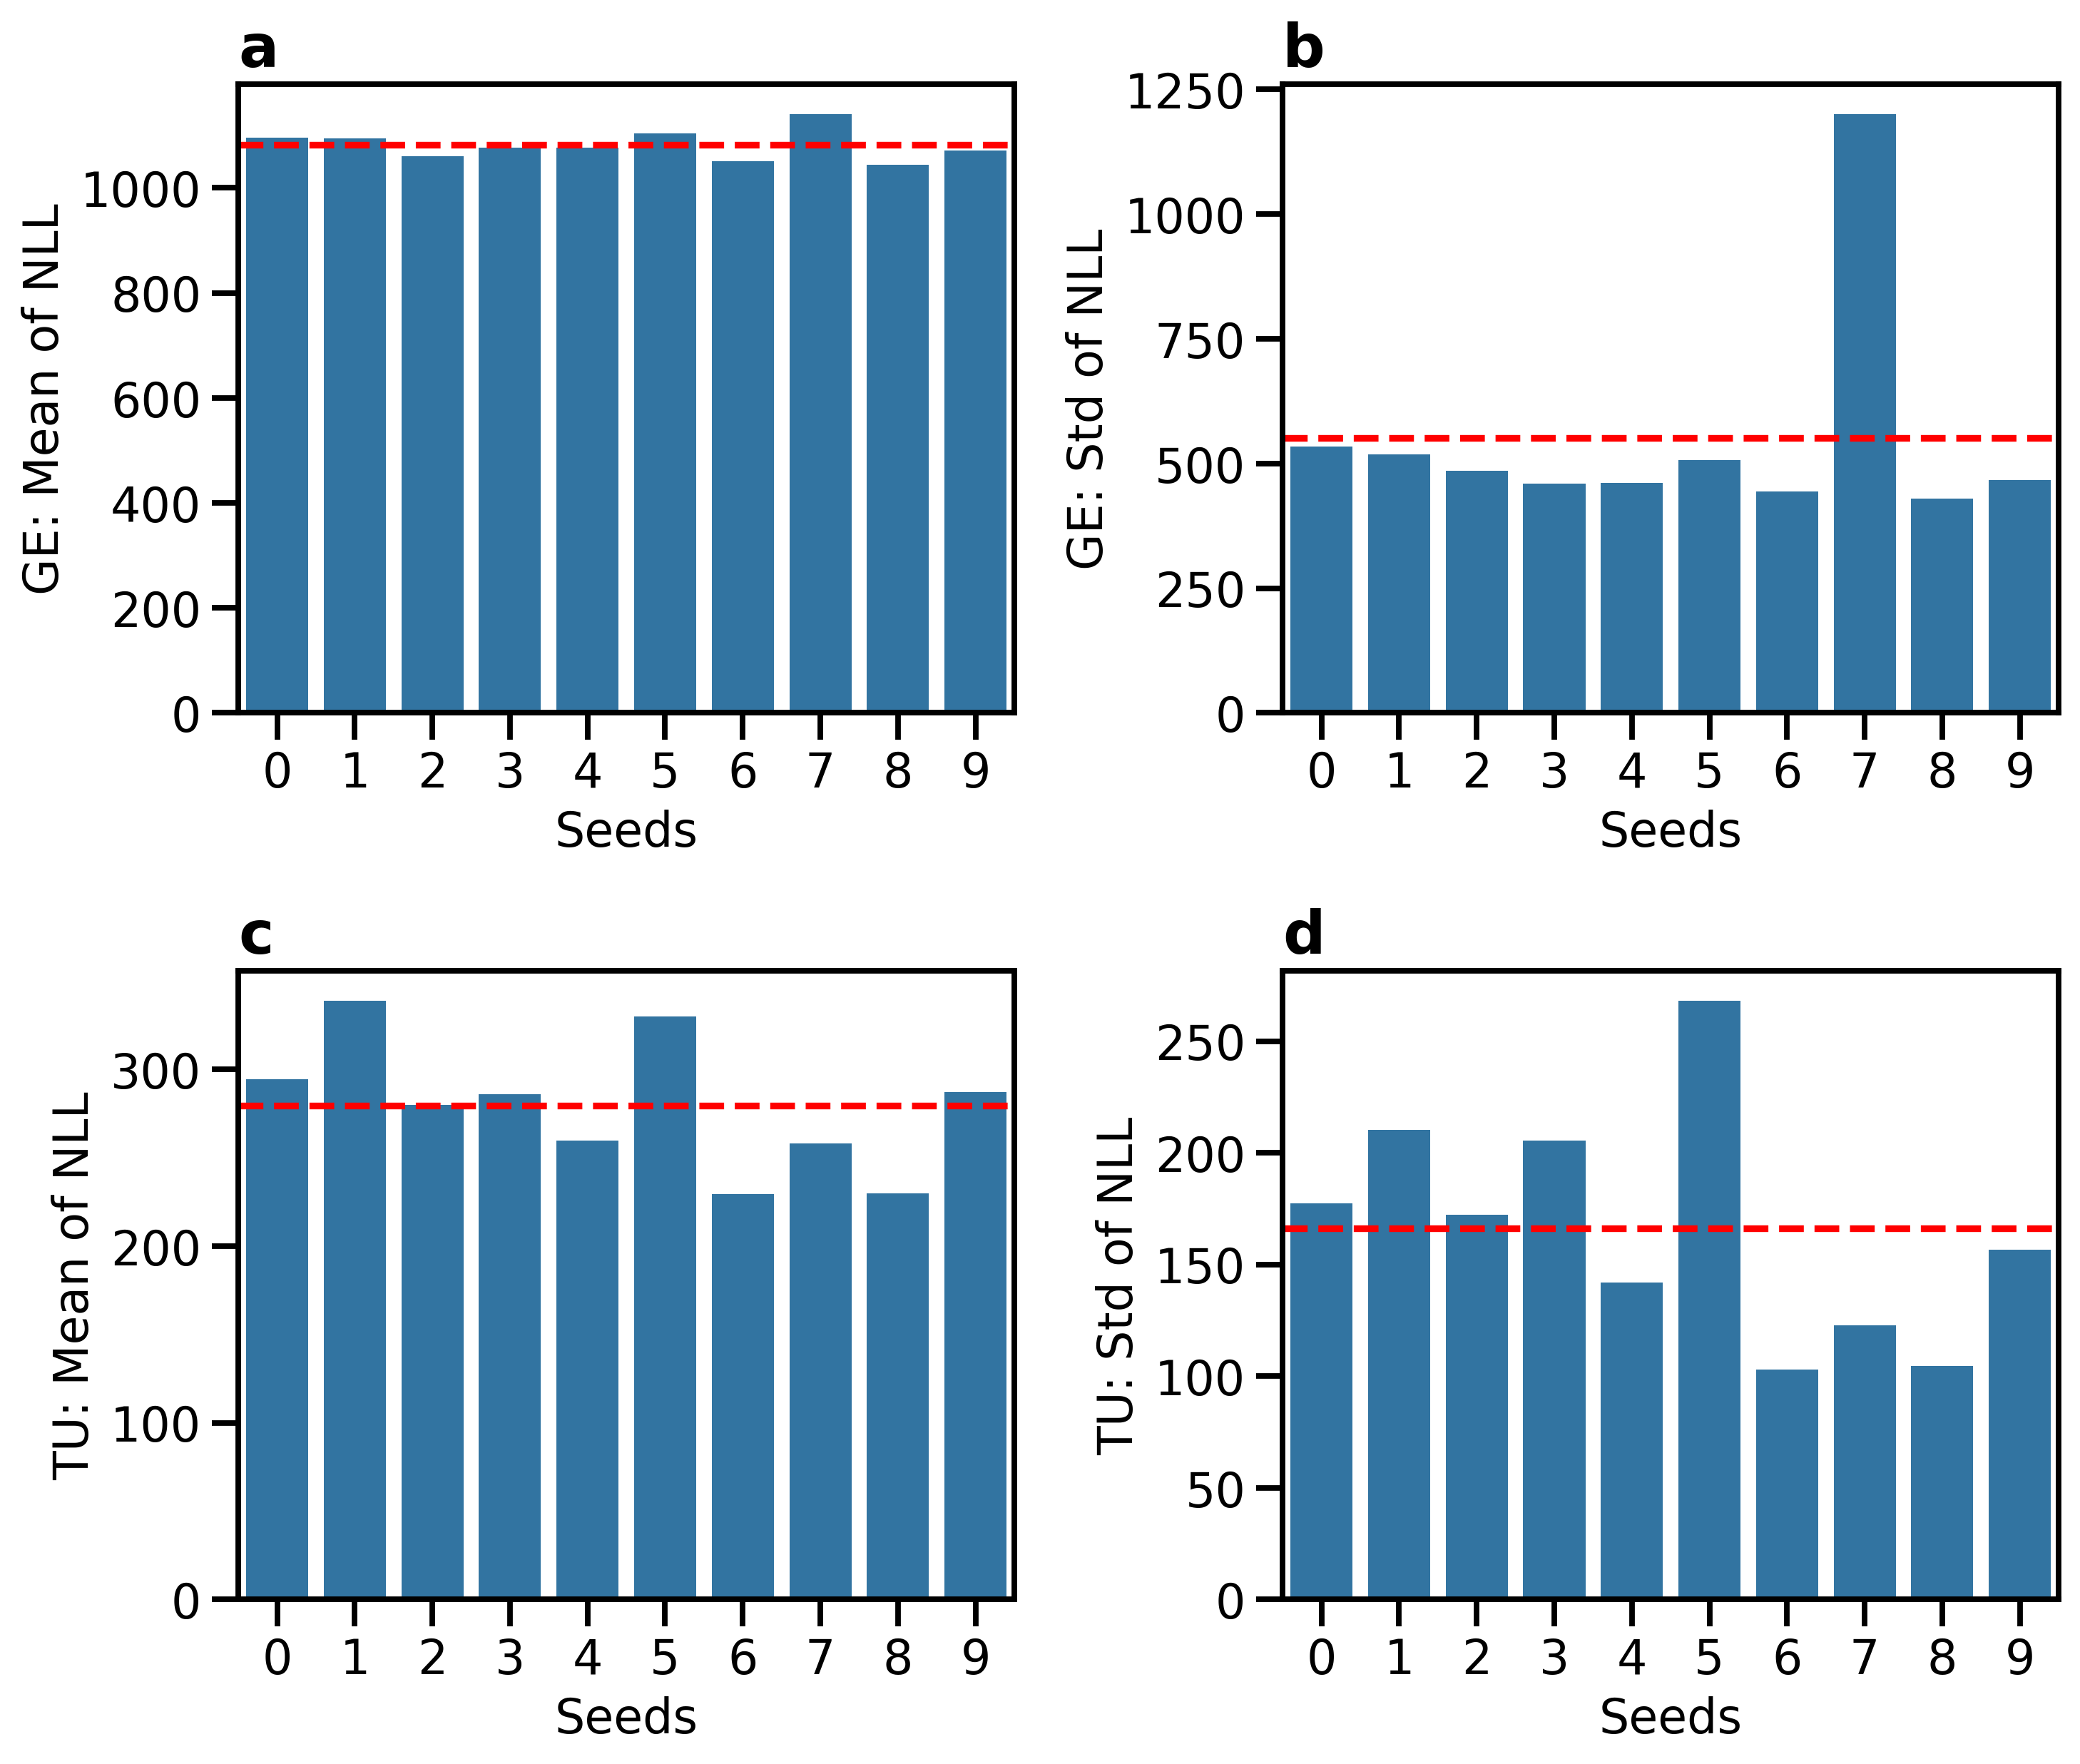

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [14]:
from crecerelle.plotting_utils import plot_random_seed_comparison_scgetuvi

# @markdown **Plotting:** Save figure
save_fig = True #@param {type:"boolean"}

# Plot the random seed comparison
plot_random_seed_comparison_scgetuvi(
        adata_tuple = (adata_GE_eval, adata_TU_eval),
        observation_models = [likelihood_1, likelihood_2],
        list_of_random_seeds = seeds,
        eval_metric_dfs = (eval_metric_df_GE, eval_metric_df_TU),
        eval_metric = eval_metric,
        save_fig =  save_fig,
        dataset_name = settings["dataset_name"]
)

For *Tabula Muris*, we choose seed 8

Visualise the latent spaces of the best scGETUVI model as UMAPs

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/

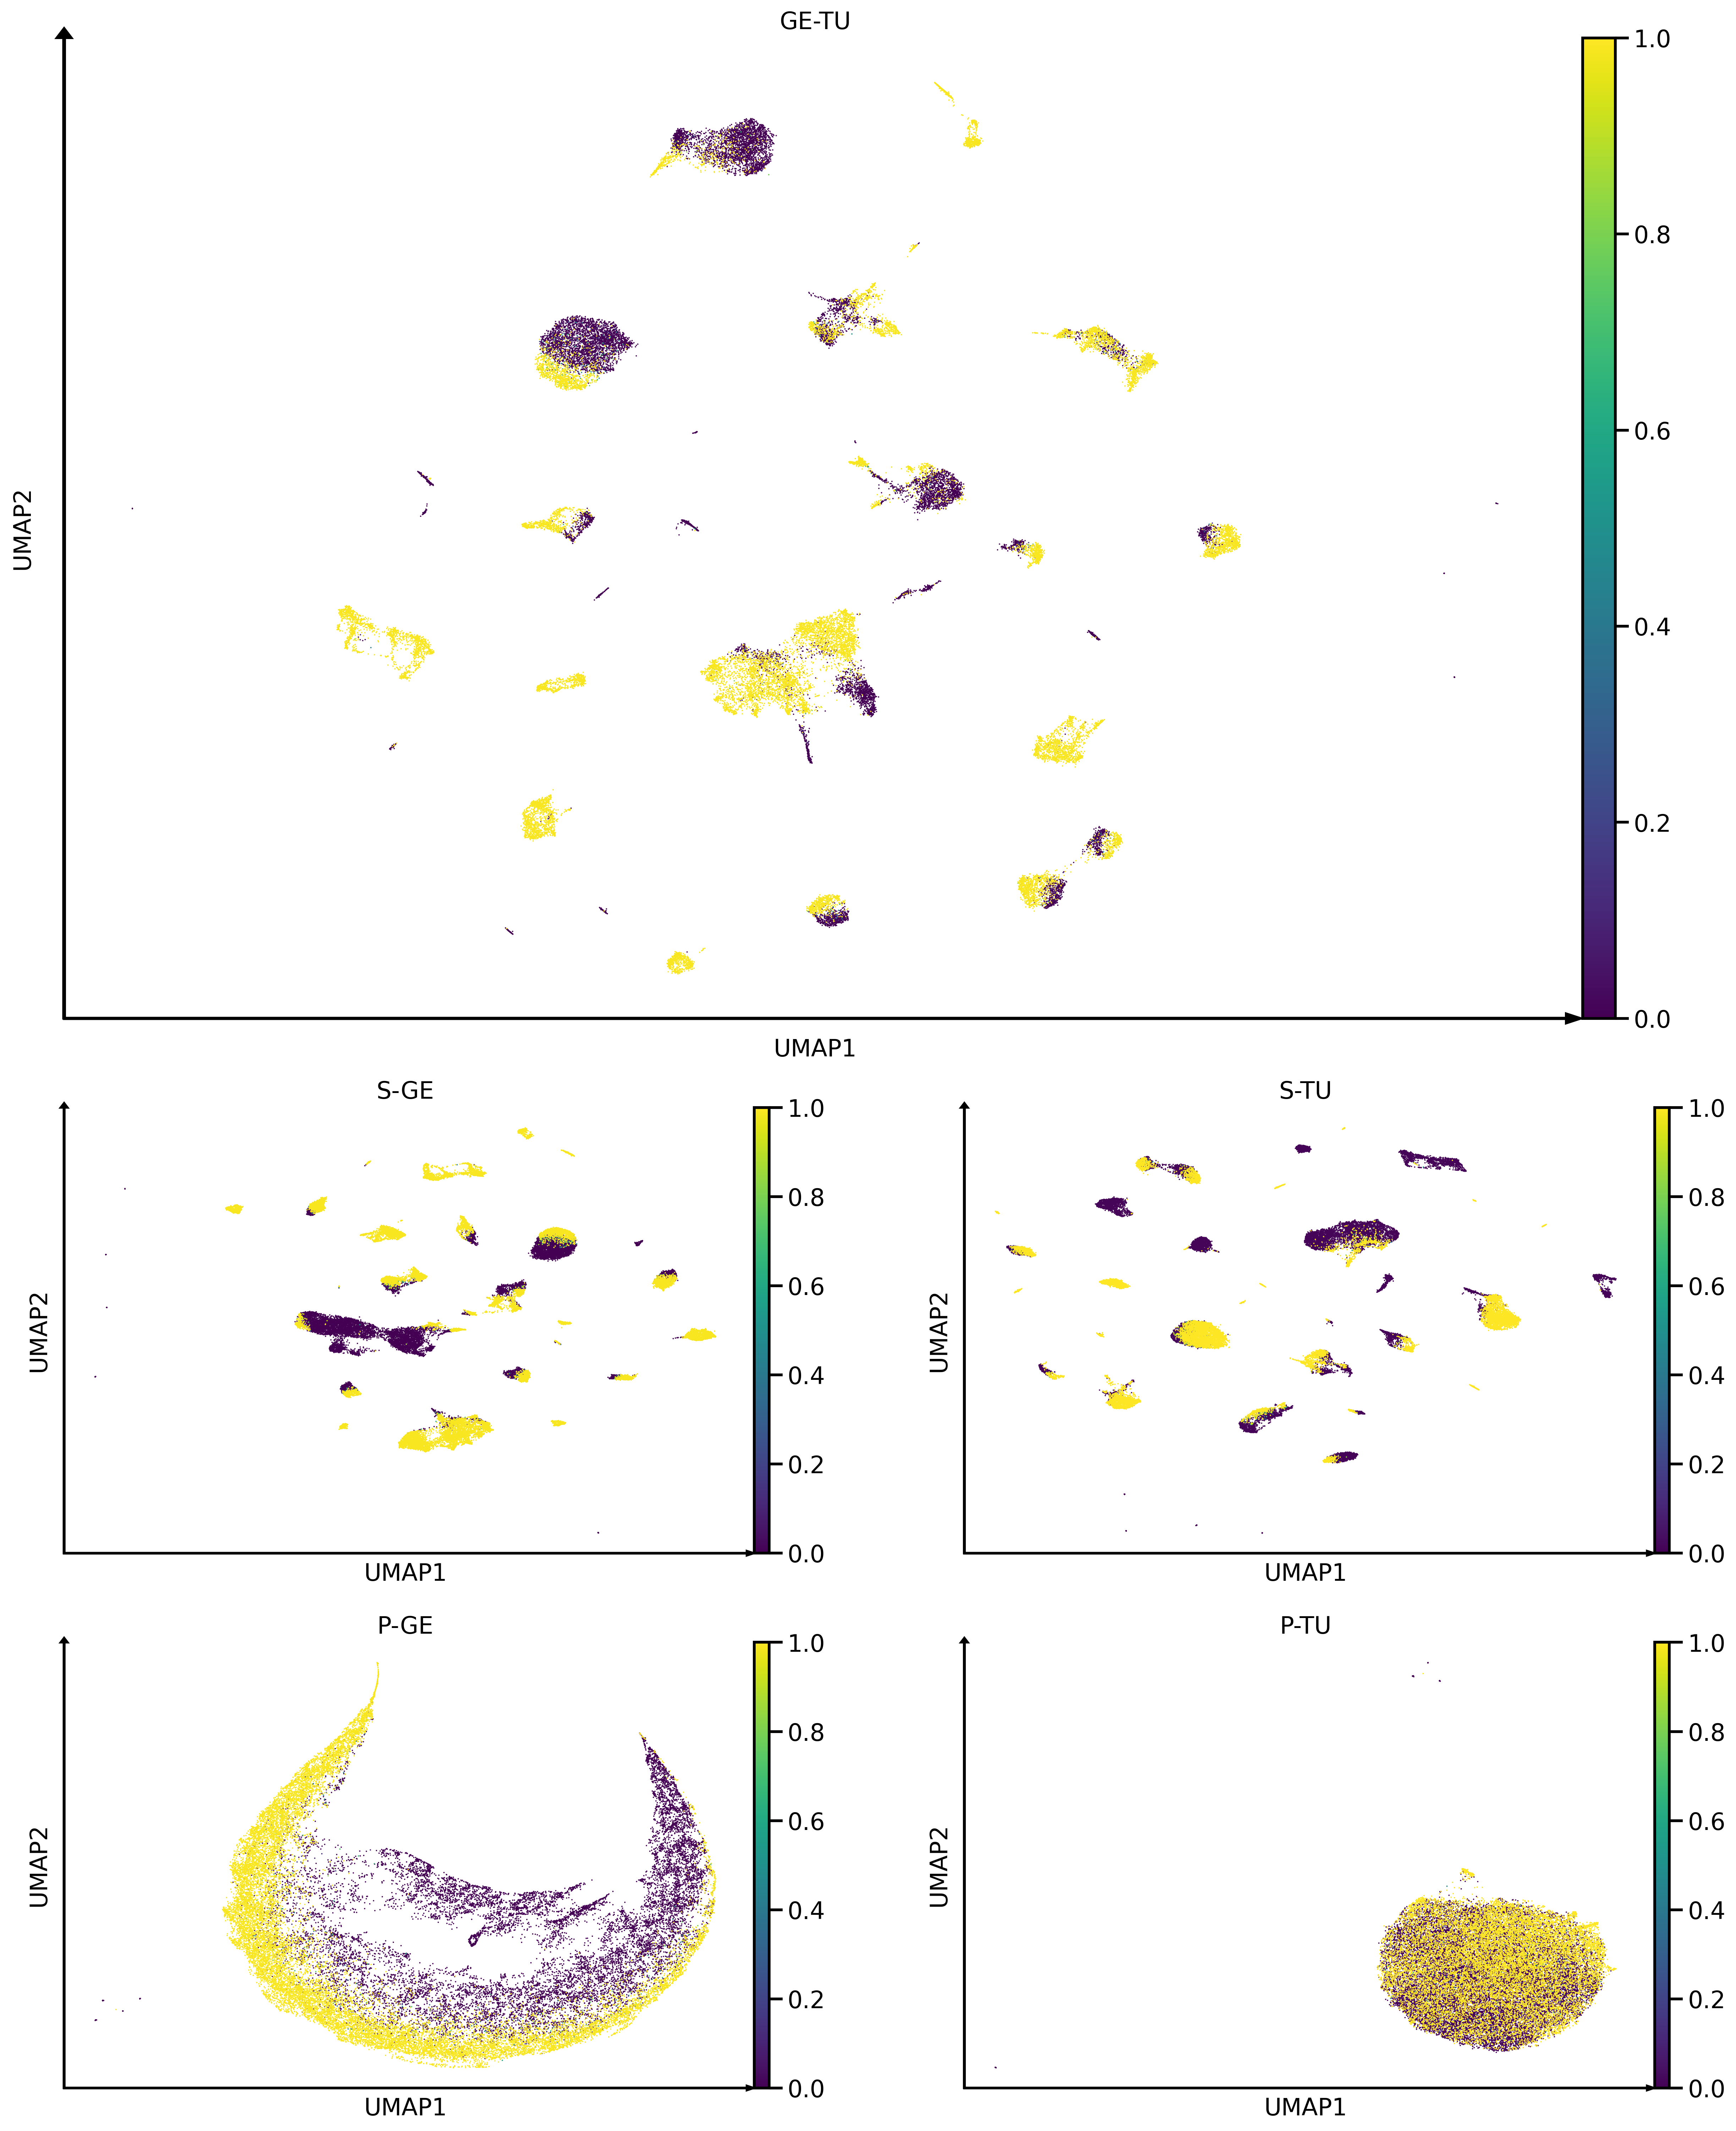

In [21]:
# @markdown **Selected seed:** Choose the seed of the scGETUVI model
seed_selected = 8 # @param

# @markdown **Cell embeddings:** Define the cell embeddings you want to analyse (e.g. S-GE, S-TU, GE-TU, P-GE, P-TU)
cell_embeddings_selected = ["S-GE", "S-TU", "GE-TU", "P-GE", "P-TU"] # @param

# @markdown **Colour key for UMAPs:** Select color key for UMAPs for gene expression (color_key_1) and transcript usage (color_key_2). We want to examine the importance weights here:

color_key_1 = likelihood_1 + "_" + str(seed_selected) + "_weighting" # @param
color_key_2 = likelihood_2 + "_" + str(seed_selected) + "_weighting" # @param


color_keys = [color_key_1, color_key_2]

adata_1_latent_space_keys = [likelihood_1 + "_" + str(seed_selected) + "_shared_latent_mean", likelihood_1 + "_" + str(seed_selected) + "_" + likelihood_2 +  "_" + str(seed_selected) + "_shared_latent_mean", likelihood_1 + "_" + str(seed_selected) + "_private_latent_mean"]
adata_2_latent_space_keys = [likelihood_2 + "_" + str(seed_selected) + "_shared_latent_mean", likelihood_2 + "_" + str(seed_selected) + "_private_latent_mean"]

# @markdown **Save figure panel:** Tick box to save the figure
save_fig = True # @param {type:"boolean"}

from crecerelle.plotting_utils import plot_umap_latent_space_scgetuvi

plot_umap_latent_space_scgetuvi(
        adata_objects = (adata_GE_eval, adata_TU_eval),
        adata_1_latent_space_keys = adata_1_latent_space_keys,
        adata_2_latent_space_keys = adata_2_latent_space_keys,
        latent_space_display = cell_embeddings_selected,
        color_key = color_keys,
        seed = seed_selected,
        dataset_name = settings["dataset_name"],
)

# Archive

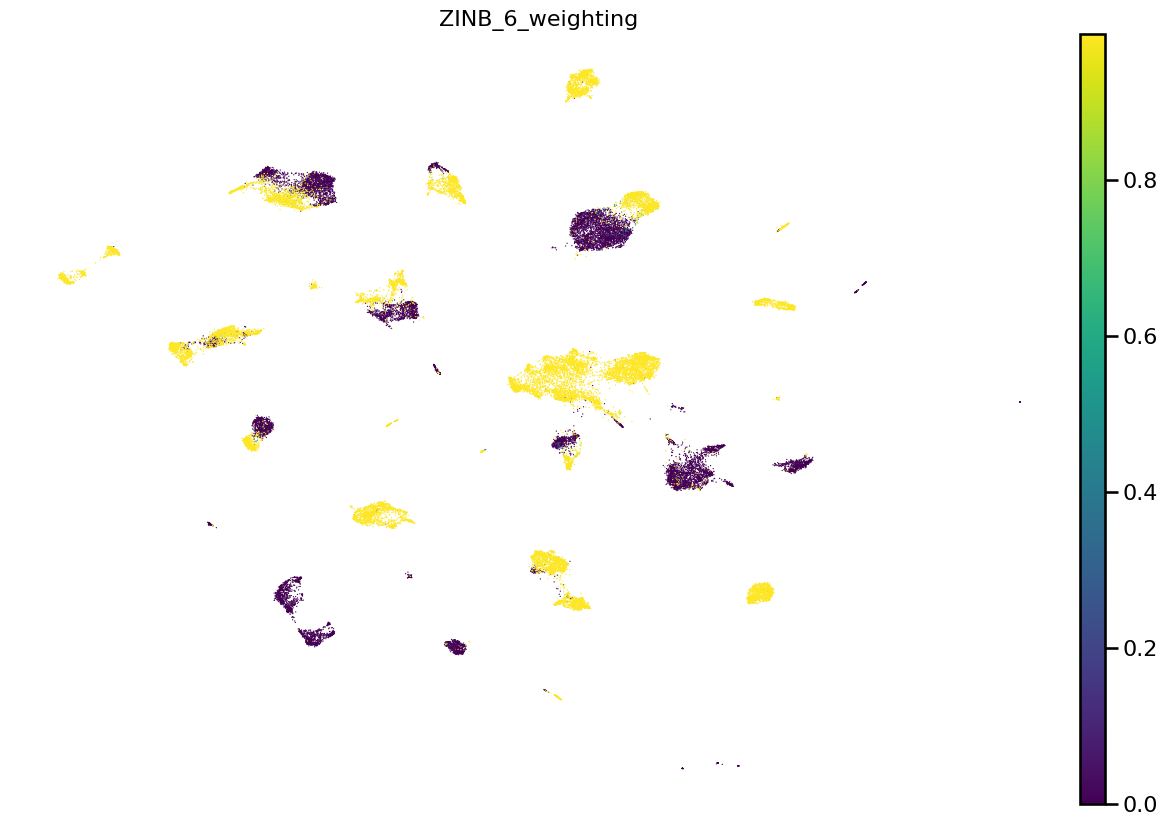

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [22]:
# Display for each seed the UMAP (Gene expression)
fig, axes = plt.subplots(1, 1, figsize=(15, 10))
emb = "shared"
color = "tissue"
weighting = "ZINB_6_weighting"

adata_GE_eval.obsm["X_umap"] = adata_GE_eval.obsm["ZINB_6_ZIDM_6_"+ emb +"_X_umap"].copy()
#adata_GE.obsm["X_umap"] = adata_GE.obsm["ZINB_5_"+ emb +"_X_umap"].copy()
sc.pl.umap(adata_GE_eval, color='ZINB_6_weighting', ax=axes ,legend_loc=None, show=False, frameon=False)
#sc.pl.umap(adata_GE, color=color, ax=axes[1] ,legend_loc=None, show=False, frameon=False)
del adata_GE_eval.obsm["X_umap"]

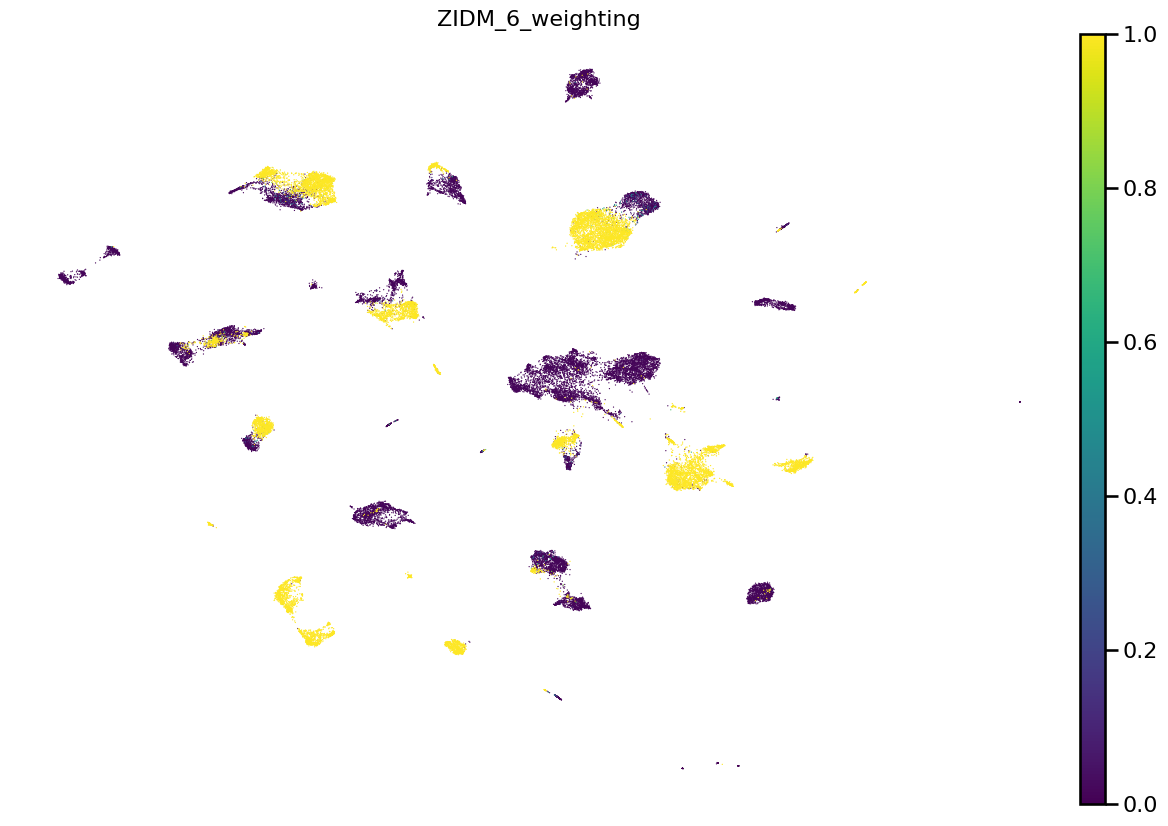

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [25]:
# Display UMAP for specific seed the UMAP (Gene expression)
fig, axes = plt.subplots(1, 1, figsize=(15, 10))
emb = "shared"
color = "tissue"
weighting = "ZIDM_6_weighting"

adata_TU_eval.obsm["X_umap"] = adata_TU_eval.obsm["ZINB_6_ZIDM_6_"+ emb +"_X_umap"].copy()
#adata_GE.obsm["X_umap"] = adata_GE.obsm["ZINB_5_"+ emb +"_X_umap"].copy()
sc.pl.umap(adata_TU_eval, color='ZIDM_6_weighting', ax=axes ,legend_loc=None, show=False, frameon=False)
#sc.pl.umap(adata_GE, color=color, ax=axes[1] ,legend_loc=None, show=False, frameon=False)
del adata_TU_eval.obsm["X_umap"]

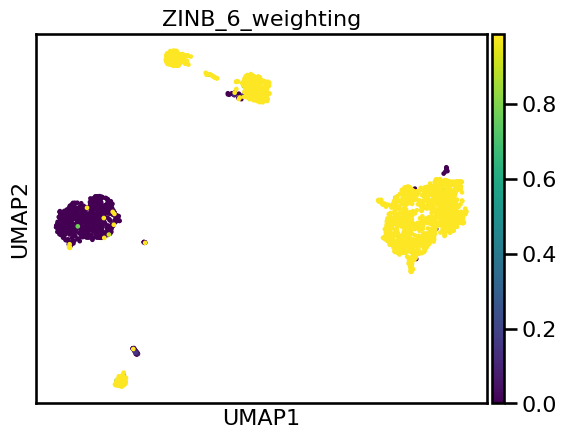

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


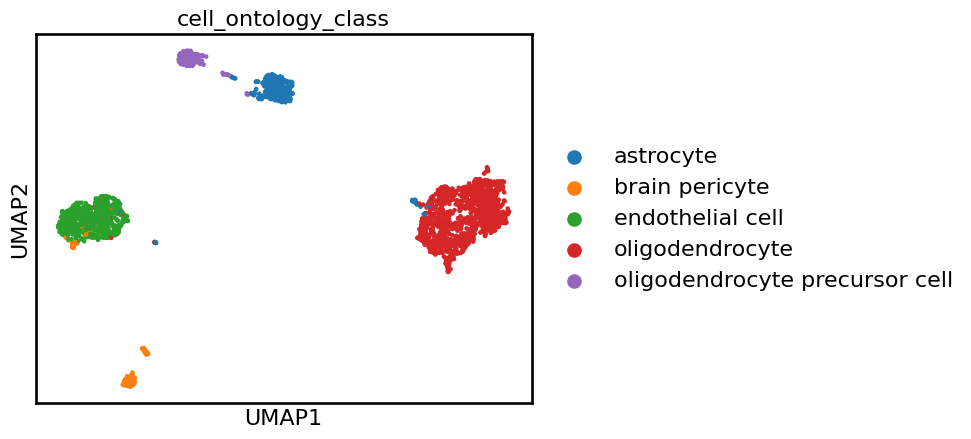

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [26]:
tissue = "Brain_Non-Myeloid" # "Brain_Non-Myeloid" #"Heart"
adata_GE_tissue = adata_GE_eval[adata_GE_eval.obs["tissue"] == tissue].copy()

# Calculate neighbourhood graph
sc.pp.neighbors(adata_GE_tissue, use_rep= "ZINB_6_ZIDM_6_shared_latent_mean")
#sc.pp.neighbors(adata_GE_tissue, use_rep= "ZINB_0_private_latent_mean")

adata_GE_tissue.obsm["X_umap"] = UMAP(n_components=2).fit_transform(adata_GE_tissue.obsm["ZINB_6_ZIDM_6_shared_latent_mean"])
#adata_GE_tissue.obsm["X_umap"] = UMAP(n_components=2).fit_transform(adata_GE_tissue.obsm["ZINB_0_private_latent_mean"])

sc.pl.umap(
    adata_GE_tissue,
    color="ZINB_6_weighting"
)

sc.pl.umap(
    adata_GE_tissue,
    color="cell_ontology_class"
)

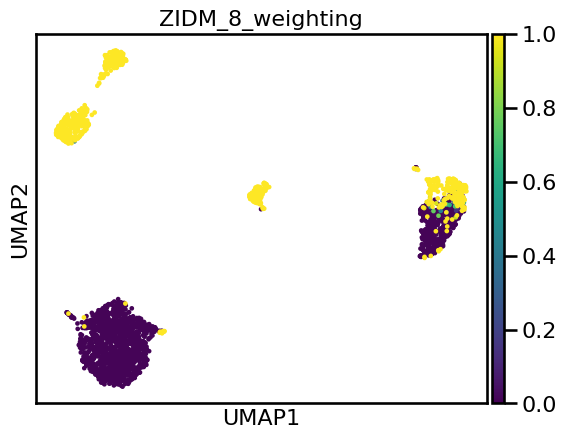

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


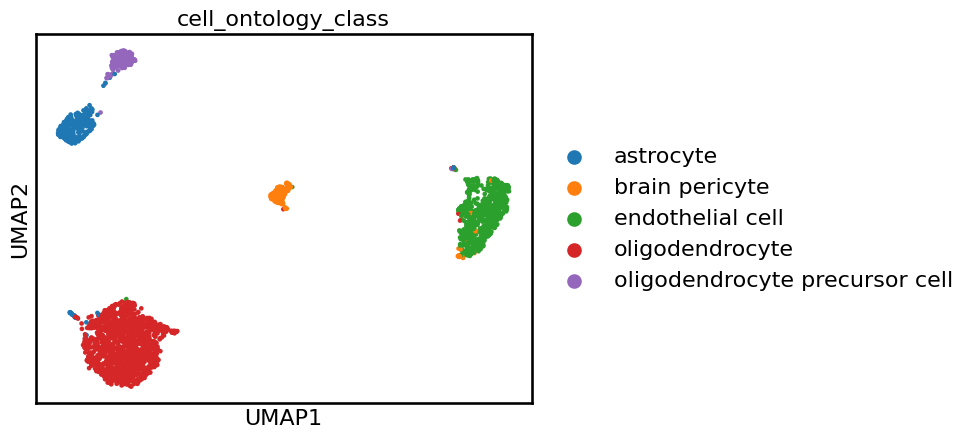

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [20]:
tissue = "Brain_Non-Myeloid" # "Brain_Non-Myeloid" #"Heart"
adata_TU_tissue = adata_TU_eval[adata_TU_eval.obs["tissue"] == tissue].copy()

# Calculate neighbourhood graph
sc.pp.neighbors(adata_TU_tissue, use_rep= "ZIDM_8_shared_latent_mean")
#sc.pp.neighbors(adata_GE_tissue, use_rep= "ZINB_0_private_latent_mean")

adata_TU_tissue.obsm["X_umap"] = UMAP(n_components=2).fit_transform(adata_TU_tissue.obsm["ZIDM_8_shared_latent_mean"])
#adata_GE_tissue.obsm["X_umap"] = UMAP(n_components=2).fit_transform(adata_GE_tissue.obsm["ZINB_0_private_latent_mean"])

sc.pl.umap(
    adata_TU_tissue,
    color="ZIDM_8_weighting"
)

sc.pl.umap(
    adata_TU_tissue,
    color="cell_ontology_class"
)